In [1]:
import os
import pandas as pd
import numpy as np
import multiprocess as mp
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.special import logsumexp
from itertools import combinations
from MetabolicWorkers import process_single_task

# Section 1: Calculate Error Values from Multiple Excel Test Files

##### Configuration

In [2]:
DATA_FOLDER = r'Data\RTA_OMNIA_Auto'
VT1_OUTPUT_FILE = "vt1_error_values.csv"
VT2_OUTPUT_FILE = "vt2_error_values.csv"

# Configurations to test (X_Axis, Y_Axis, which_vt)
VT1_TEST_CONFIGURATIONS = [
    ("V-Slope", None, 'vt1'),
    ("VO2", "VCO2", 'vt1'),
    ("VO2", "VE/VO2", 'vt1'),
    ("VO2", "PetO2", 'vt1'),
    ("VO2", "excess_co2", 'vt1'),
    ("RQ=", 0.85, 'vt1'),
    ("high_rer_mask", 1.0, 'vt1'),
    ("fat_max_mask", None, 'vt1')
]

VT2_TEST_CONFIGURATIONS = [
    ("VO2", "VE/VCO2", 'vt2'),
    ("VO2", "PetCO2", 'vt2'),
    ("RQ=", 1.0, 'vt2'),
    ("VO2", "excess_Ve", 'vt2')
]

##### Process Tests

In [3]:
def batch_process_parallel(folder_path, test_configurations, output_csv):
    files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]
    tasks = [(os.path.join(folder_path, f), conf, f) for f in files for conf in test_configurations]

    print(f"Spinning up {mp.cpu_count()} workers...")
    
    # Multiprocess
    with mp.Pool(processes=mp.cpu_count()) as pool:
        results_of_lists = pool.map(process_single_task, tasks)
        
    all_results = [item for sublist in results_of_lists for item in sublist]
    final_df = pd.DataFrame(all_results)
    final_df.to_csv(output_csv, index=False)
    
    return final_df
    
# Process VT1
print("\n" + "="*30)
print("VT1 BATCH PROCESSING BEGIN") 
print("="*30)
print()
    
vt1_results = batch_process_parallel(DATA_FOLDER, VT1_TEST_CONFIGURATIONS, VT1_OUTPUT_FILE)
#vt1_results = None
if vt1_results is not None:
    print("\n" + "="*30)
    print("VT1 BATCH PROCESSING COMPLETE")
    print(f"Trials Processed: {len(vt1_results)}")
    print(f"Results saved to: {VT1_OUTPUT_FILE}")
    print("="*30)

# Process VT2
print("\n" + "="*30)
print("VT2 BATCH PROCESSING BEGIN") 
print("="*30)
print()

vt2_results = batch_process_parallel(DATA_FOLDER, VT2_TEST_CONFIGURATIONS, VT2_OUTPUT_FILE)
#vt2_results = None
if vt2_results is not None:
    print("\n" + "="*30)
    print("VT2 BATCH PROCESSING COMPLETE")
    print(f"Trials Processed: {len(vt2_results)}")
    print(f"Results saved to: {VT2_OUTPUT_FILE}")
    print("="*30)



VT1 BATCH PROCESSING BEGIN

Spinning up 24 workers...

VT1 BATCH PROCESSING COMPLETE
Trials Processed: 10040
Results saved to: vt1_error_values.csv

VT2 BATCH PROCESSING BEGIN

Spinning up 24 workers...

VT2 BATCH PROCESSING COMPLETE
Trials Processed: 5996
Results saved to: vt2_error_values.csv


# Section 2: Process All VT1 Combinations

##### Configuration

In [4]:
true_values = {
    "01 01 20260116 CPET BxB_20260210095828.xlsx": 1.931, "02 02 20260123 CPET BxB_20260210095834.xlsx": 1.735,
    "03 03 20250213 CPET BxB_20260210095838.xlsx": 1.564, "04 04 20260115 CPET BxB_20260210095833.xlsx": 1.428,
    "05 05 20260126 CPET BxB_20260210095829.xlsx": 1.344, "06 06 20260127 CPET BxB_20260210095833.xlsx": 2.807,
    "07 07 20260114 CPET BxB_20260210095835.xlsx": 2.504, "08 08 20260126 CPET BxB_20260210095839.xlsx": 1.309,
    "09 09 20260127 CPET BxB_20260210095826.xlsx": 1.234, "10 10 20260128 CPET BxB_20260210095831.xlsx": 1.478,
    "11 11 20260114 CPET BxB_20260210095836.xlsx": 1.085, "12 12 20260116 CPET BxB_20260210095838.xlsx": 1.574,
    "13 13 20260121 CPET BxB_20260210095830.xlsx": 1.360, "14 14 20260204 CPET BxB_20260210095837.xlsx": 1.677,
    "15 15 20260204 CPET BxB_20260210095826.xlsx": 1.814, "16 16 20260121 CPET BxB_20260210095832.xlsx": 1.812,
    "17 17 20260126 CPET BxB_20260210095836.xlsx": 1.142, "18 18 20260126 CPET BxB_20260210095834.xlsx": 1.679,
    "19 19 20170929 CPET BxB_20260210095832.xlsx": 2.975, "20 20 20250422 CPET BxB_20260210095849.xlsx": 2.659,
    "21 21 20140130 CPET BxB_20260210095840.xlsx": 2.372, "22 22 20160204 CPET BxB_20260210095826.xlsx": 3.275,
    "23 23 20160307 CPET BxB_20260210095839.xlsx": 2.267, "24 24 20260126 CPET BxB_20260210095827.xlsx": 1.558,
    "25 25 20160210 CPET BxB_20260210095828.xlsx": 1.966, "26 26 20260126 CPET BxB_20260210095833.xlsx": 3.152,
    "27 27 20250826 CPET BxB_20260210095835.xlsx": 2.532, "28 28 20160208 CPET BxB_20260210095837.xlsx": 2.468,
    "29 29 20220502 CPET BxB_20260210095830.xlsx": 2.297, "30 30 20250808 CPET BxB_20260210095831.xlsx": 1.531,
    "31 31 20250825 CPET BxB_20260210095827.xlsx": 2.904, "32 32 20250630 CPET BxB_20260210095829.xlsx": 1.669
}

methods = [
    "V-Slope",
    "VCO2_vs_VO2",
    "VE/VO2_vs_VO2",
    "PetO2_vs_VO2",
    "excess_co2_vs_VO2",
    "RQ=0.85",
    "High_RER_1.0_Mask",
    "FatMax_Mask",
]

##### Run all combinations

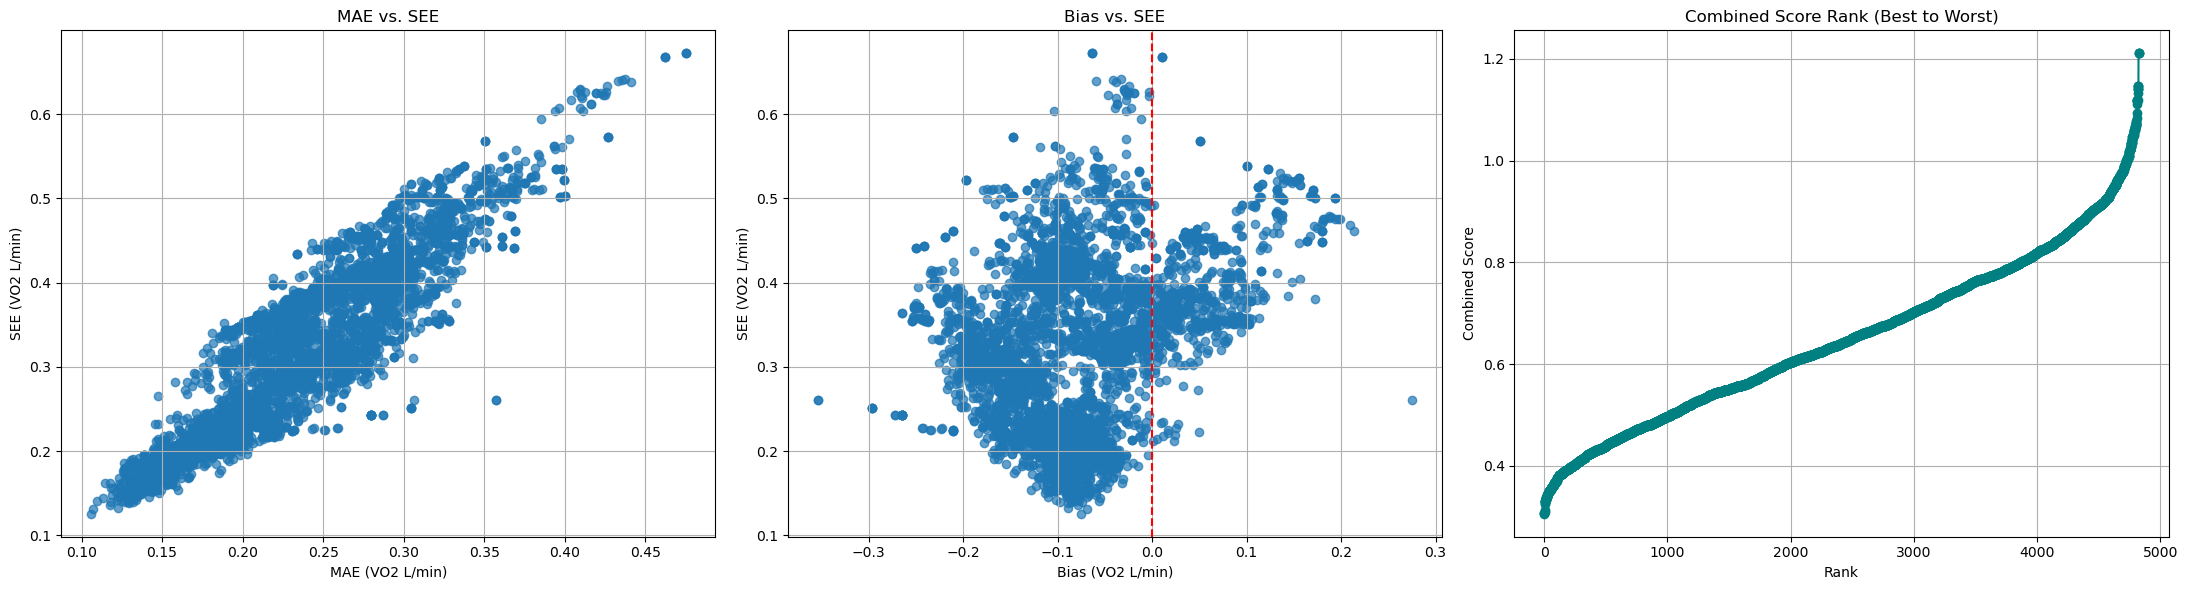

,Strategy,Smoothing_Scope,Combination,Methods_Used,MAE,Mean_Error,SEE,Combined_Score
0,Rolling 7pt,Both,V-Slope + VE/VO2 + excess + RQ=0.85 + High + F...,"[V-Slope, VE/VO2_vs_VO2, excess_co2_vs_VO2, RQ...",0.109582,-0.056488,0.140202,0.306273
1,Rolling 7pt,Both,VE/VO2 + excess + RQ=0.85 + High + FatMax,"[VE/VO2_vs_VO2, excess_co2_vs_VO2, RQ=0.85, Hi...",0.105930,-0.075206,0.125638,0.306774
2,Rolling 7pt,Both,VE/VO2 + excess + RQ=0.85 + FatMax,"[VE/VO2_vs_VO2, excess_co2_vs_VO2, RQ=0.85, Fa...",0.107242,-0.069373,0.131432,0.308047
3,Rolling 5pt,Avg Only,V-Slope + VE/VO2 + excess + RQ=0.85 + FatMax,"[V-Slope, VE/VO2_vs_VO2, excess_co2_vs_VO2, RQ...",0.114680,-0.031766,0.162594,0.309041
4,Rolling 7pt,Both,V-Slope + VE/VO2 + excess + RQ=0.85 + FatMax,"[V-Slope, VE/VO2_vs_VO2, excess_co2_vs_VO2, RQ...",0.113229,-0.055480,0.144681,0.313391
5,Gaussian 2.0,Both,V-Slope + VE/VO2 + excess + RQ=0.85 + High + F...,"[V-Slope, VE/VO2_vs_VO2, excess_co2_vs_VO2, RQ...",0.118731,-0.059614,0.147666,0.326011
6,Gaussian 2.0,Both,V-Slope + VE/VO2 + excess + RQ=0.85 + FatMax,"[V-Slope, VE/VO2_vs_VO2, excess_co2_vs_VO2, RQ...",0.123096,-0.048039,0.156609,0.327744
7,Rolling 7pt,Both,V-Slope + VE/VO2 + excess + High + FatMax,"[V-Slope, VE/VO2_vs_VO2, excess_co2_vs_VO2, Hi...",0.132390,-0.030503,0.167332,0.330225
8,Gaussian 2.0,Both,VE/VO2 + excess + RQ=0.85 + FatMax,"[VE/VO2_vs_VO2, excess_co2_vs_VO2, RQ=0.85, Fa...",0.121206,-0.059135,0.150915,0.331256
9,Rolling 7pt,Both,V-Slope + VCO2 + VE/VO2 + RQ=0.85 + High + FatMax,"[V-Slope, VCO2_vs_VO2, VE/VO2_vs_VO2, RQ=0.85,...",0.117485,-0.078325,0.135864,0.331674


In [5]:
# LOAD & PREPARE DATA
df_raw = pd.read_csv('vt1_error_values.csv')
df = df_raw.pivot(index=['FileName', 'Time', 'VO2'], columns='Method', values='Normalized_Error').reset_index()
df.columns.name = None

# --- 1. CONFIGURATION ---
# Define the base smoothing tasks (Type, Value, Label)
base_tasks = [
    ('none', 0, 'No Smoothing'),
    ('rolling', 3, 'Rolling 3pt'),
    ('rolling', 5, 'Rolling 5pt'),
    ('rolling', 7, 'Rolling 7pt'),
    ('gaussian', 0.25, 'Gaussian 0.25'),
    ('gaussian', 0.5,  'Gaussian 0.5'),
    ('gaussian', 0.6,  'Gaussian 0.6'),
    ('gaussian', 0.8,  'Gaussian 0.8'),
    ('gaussian', 1.0,  'Gaussian 1.0'),
    ('gaussian', 2.0,  'Gaussian 2.0')
]

all_test_results = []

# --- 2. OUTERMOST LOOP: SCOPE (Both vs. Average Only) ---
for smooth_both in [True, False]:
    scope_label = "Both" if smooth_both else "Avg Only"
    
    # --- 3. MIDDLE LOOP: SMOOTHING STRATEGY ---
    for s_type, s_val, s_label in base_tasks:
        
        # Skip 'none' for the True/False loop to avoid redundant 'No Smoothing' results
        if s_type == 'none' and smooth_both is False:
            continue

        for r in range(1, len(methods) + 1):
            for combo in combinations(methods, r):
                combo_list = list(combo)
                
                # Fresh copy for this specific pass
                temp_df = df[['FileName', 'VO2'] + combo_list].copy()
                
                # --- 4. OPTIONAL: SMOOTH INDIVIDUAL COLUMNS ---
                if smooth_both and s_type != 'none':
                    for col in combo_list:
                        if s_type == 'rolling':
                            temp_df[col] = temp_df.groupby('FileName')[col].transform(
                                lambda x: x.rolling(window=s_val, center=True).mean().combine_first(x)
                            )
                        elif s_type == 'gaussian':
                            temp_df[col] = temp_df.groupby('FileName')[col].transform(
                                lambda x: gaussian_filter1d(x, sigma=s_val)
                            )

                # --- CALCULATE AVERAGE ---
                temp_df['Temp_Average'] = temp_df[combo_list].mean(axis=1, skipna=True)
                
                # --- ALWAYS SMOOTH THE FINAL AVERAGE (If not 'none') ---
                if s_type != 'none':
                    if s_type == 'rolling':
                        temp_df['Temp_Average'] = temp_df.groupby('FileName')['Temp_Average'].transform(
                            lambda x: x.rolling(window=s_val, center=True).mean().combine_first(x)
                        )
                    elif s_type == 'gaussian':
                        temp_df['Temp_Average'] = temp_df.groupby('FileName')['Temp_Average'].transform(
                            lambda x: gaussian_filter1d(x, sigma=s_val)
                        )

                # --- 7. SELECTION & ERROR CALCULATION ---
                best_indices = temp_df.groupby('FileName')['Temp_Average'].idxmin()
                df_selections = temp_df.loc[best_indices].copy()
                df_selections['True_VO2'] = df_selections['FileName'].map(true_values)
                
                df_selections['Error'] = df_selections['VO2'] - df_selections['True_VO2']
                df_selections['Abs_Error'] = df_selections['Error'].abs()
                
                all_test_results.append({
                    "Strategy": s_label,
                    "Smoothing_Scope": scope_label,
                    "Combination": " + ".join([m.split('_')[0] for m in combo_list]),
                    "Methods_Used": combo_list,
                    "MAE": df_selections['Abs_Error'].mean(),
                    "Mean_Error": df_selections['Error'].mean(),
                    "SEE": df_selections['Error'].std()
                })

# --- RESULTS SUMMARY ---
results_df_original = pd.DataFrame(all_test_results)
results_df_original['Combined_Score'] = results_df_original['MAE'] + results_df_original['Mean_Error'].abs() + results_df_original['SEE']
results_df_original = results_df_original.sort_values('Combined_Score').reset_index(drop=True)
results_df = results_df_original.copy()

# Optional: Hide outliers
results_df = results_df[results_df['Combined_Score'] < 1.25].copy()

# VISUALIZATION
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# MAE vs SEE
scatter1 = ax1.scatter(results_df['MAE'], results_df['SEE'], alpha=0.7)
ax1.set_title('MAE vs. SEE')
ax1.set_xlabel('MAE (VO2 L/min)'); ax1.set_ylabel('SEE (VO2 L/min)'); ax1.grid(True)

# Bias vs SEE
scatter2 = ax2.scatter(results_df['Mean_Error'], results_df['SEE'], alpha=0.7)
ax2.axvline(0, color='red', linestyle='--'); ax2.set_title('Bias vs. SEE')
ax2.set_xlabel('Bias (VO2 L/min)'); ax2.set_ylabel('SEE (VO2 L/min)'); ax2.grid(True)

# Score Rank
ax3.plot(results_df.index, results_df['Combined_Score'], marker='o', color='teal')
ax3.set_title('Combined Score Rank (Best to Worst)')
ax3.set_xlabel('Rank'); ax3.set_ylabel('Combined Score'); ax3.grid(True)

plt.tight_layout()
#plt.savefig("vt1_performance_results.png", dpi=300, bbox_inches='tight')
plt.show()

results_df = results_df_original

# SAVE
results_df.to_csv("vt1_ranked_combinations.csv", index=False)
display(results_df.head(30))

##### Get Average Rankings

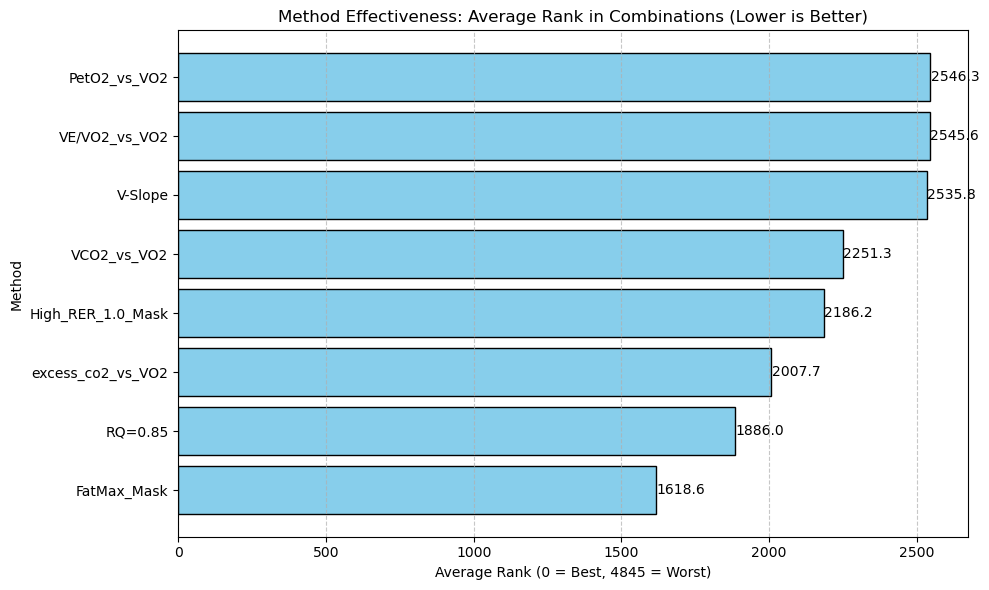

--- Average Rank per Method ---


,Average_Rank
FatMax_Mask,1618.572368
RQ=0.85,1886.041941
excess_co2_vs_VO2,2007.725329
High_RER_1.0_Mask,2186.210115
VCO2_vs_VO2,2251.292763
V-Slope,2535.827303
VE/VO2_vs_VO2,2545.569901
PetO2_vs_VO2,2546.284128


In [6]:
# CALCULATE AVERAGE RANK FOR EACH METHOD
method_ranks = {m: [] for m in methods}

# results_df is assumed to be sorted by Combined_Score (best to worst)
for idx, row in results_df.iterrows():
    for method in row['Methods_Used']:
        method_ranks[method].append(idx)

# Create a summary dataframe of average ranks
avg_rank_df = pd.DataFrame({m: np.mean(ranks) for m, ranks in method_ranks.items()}, index=['Average_Rank']).T
avg_rank_df = avg_rank_df.sort_values(by='Average_Rank')

# Plot effectiveness
plt.figure(figsize=(10, 6))
bars = plt.barh(avg_rank_df.index, avg_rank_df['Average_Rank'], color='skyblue', edgecolor='black')

# Labeling
plt.title('Method Effectiveness: Average Rank in Combinations (Lower is Better)')
plt.xlabel(f'Average Rank (0 = Best, {len(results_df)} = Worst)')
plt.ylabel('Method')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}', va='center')

plt.tight_layout()
plt.show()

# Display the numerical table
print("--- Average Rank per Method ---")
display(avg_rank_df)

# Section 3: Get VT1 Selections For a Set of Excel Tests 

##### Load Data

In [7]:
df = pd.read_csv('vt1_error_values.csv')

# index: columns to keep as they are
# columns: the values in this column become the new column headers
# values: the values that will fill the new columns
df = df.pivot(index=['FileName', 'Time', 'VO2'], columns='Method', values='Normalized_Error').reset_index()

# Remove the name of the columns index
df.columns.name = None

# Print method columns
METHOD_COLS = [col for col in df.columns if col not in ['FileName', 'Time', 'VO2']]
print("Available Method Columns:")
for method in METHOD_COLS:
    print(f'    {method}')

Available Method Columns:
    FatMax_Mask
    High_RER_1.0_Mask
    PetO2_vs_VO2
    RQ=0.85
    V-Slope
    VCO2_vs_VO2
    VE/VO2_vs_VO2
    excess_co2_vs_VO2


##### Configuration

In [8]:
SMOOTH_METHOD = True
SMOOTH_AVERAGE = True
FILTER_TYPE = 'gaussian'  # Options: 'none', 'rolling' or 'gaussian'
WINDOW_SIZE = 1           # Number of data points for the window/sigma
# List of specific columns to include in the average
COLS_TO_AVERAGE = [
    "FatMax_Mask",
    "High_RER_1.0_Mask",
    "excess_co2_vs_VO2",
    #"Ve/VO2_vs_VO2",
    "VCO2_vs_VO2",
    #"V-Slope",
    "RQ=0.85"
]

##### Smooth and Average Data

In [9]:
def smooth_data(series, filter_type, window_size):
    if filter_type == 'none':
        return series
    elif filter_type == 'rolling':
        return series.rolling(window=window_size, center=True, min_periods=1).mean()
    elif filter_type == 'gaussian':
        return gaussian_filter1d(series, sigma=window_size)
    return series

# -------------------------------------------------------
# Smooth Method Columns
# -------------------------------------------------------
if SMOOTH_METHOD:
    cols_to_smooth = [col for col in METHOD_COLS if "Mask" not in col]

    if cols_to_smooth:
        # Apply the chosen filter per FileName
        df[cols_to_smooth] = df.groupby('FileName')[cols_to_smooth].transform(smooth_data, filter_type=FILTER_TYPE, window_size=WINDOW_SIZE)
        print(f"Filter applied to method columns: {FILTER_TYPE} (window/sigma: {WINDOW_SIZE})")

    cols_skipped = [col for col in METHOD_COLS if "Mask" in col]
    if cols_skipped:
        print(f"Skipped smoothing for: {', '.join(cols_skipped)}")

# -------------------------------------------------------
# Average Chosen Methods
# -------------------------------------------------------
# Calculate the row-wise (axis=1) average
df['Average'] = df[COLS_TO_AVERAGE].mean(axis=1)

print("Average calculated using columns:")
for c in COLS_TO_AVERAGE:
    print(f'    {c}')
print()

# -------------------------------------------------------
# Smooth average column
# -------------------------------------------------------
if SMOOTH_AVERAGE:
    df["Average"] = df.groupby('FileName')["Average"].transform(smooth_data, filter_type=FILTER_TYPE, window_size=WINDOW_SIZE)
    
    print(f"Filter applied to average column: {FILTER_TYPE} (window/sigma: {WINDOW_SIZE})")

Filter applied to method columns: gaussian (window/sigma: 1)
Skipped smoothing for: FatMax_Mask, High_RER_1.0_Mask
Average calculated using columns:
    FatMax_Mask
    High_RER_1.0_Mask
    excess_co2_vs_VO2
    VCO2_vs_VO2
    RQ=0.85

Filter applied to average column: gaussian (window/sigma: 1)


##### Create Plots

In [10]:
# --- SETTINGS ---
COLUMNS_TO_PLOT = COLS_TO_AVERAGE.copy()
COLUMNS_TO_PLOT.append("Average")
output_folder = "VT1_Plots"

# Create the folder if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created folder: {output_folder}")

# Get all unique filenames
all_files = df['FileName'].unique()

print(f"Starting batch plot for {len(all_files)} files...")

for file_name in all_files:
    subset = df[df['FileName'] == file_name]
    
    # Skip if subset is somehow empty
    if subset.empty:
        continue
        
    plt.figure(figsize=(12, 7))
    
    # Loop through each column and plot it
    for col in COLUMNS_TO_PLOT:
        if col == "Average":
            plt.plot(subset['VO2'], subset[col], label=col, linewidth=2, marker='o', markersize=2.5, alpha=0.75)
        else:    
            plt.plot(subset['VO2'], subset[col], label=col, linewidth=0.5, marker='o', markersize=1, alpha=0.25)
    
    # --- Threshold Detection Logic ---
    if "Average" in subset.columns:
        min_err_idx = subset['Average'].idxmin()
        get_vo2 = subset.loc[min_err_idx, 'VO2']
        
        plt.axvline(x=get_vo2, color='red', linestyle='--', 
                    label=f'Min Average Error ({get_vo2:.3f} L/min)')
    
    # Adding titles and labels
    plt.title(f"VT1 Error vs. $VO_2$\nFile: {file_name}", fontsize=14)
    plt.xlabel("$VO_2$ (L/min)", fontsize=12)
    plt.ylabel("Normalized Error", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # Replace characters that might break file paths (like .xlsx) with underscores
    clean_filename = str(file_name).replace('.', '_')
    
    # Save the plot
    save_path = os.path.join(output_folder, f"{clean_filename}_vt1.png")
    plt.savefig(save_path, dpi=150)
    plt.close()

print(f"Done! All plots have been saved to the '{output_folder}' folder.")

Starting batch plot for 32 files...
Done! All plots have been saved to the 'VT1_Plots' folder.


##### Get Results for Each File

In [11]:
# Find the index of the minimum 'Average' for each FileName
best_indices = df.groupby('FileName')['Average'].idxmin()

# Use those indices to pull the full rows from the original dataframe
# Only select the following columns: FileName, Time, and VO2
df_best_points = df.loc[best_indices, ['FileName', 'Time', 'VO2']].copy().reset_index(drop=True)

# Print results
print("--- Summary of Best VT1 Threshold Points ---")
display(df_best_points)

# Save results
df_best_points.to_csv("vt1_threshold_points.csv", index=False)

--- Summary of Best VT1 Threshold Points ---


,FileName,Time,VO2
0,01 01 20260116 CPET BxB_20260210095828.xlsx,00:08:15,2.125837
1,02 02 20260123 CPET BxB_20260210095834.xlsx,00:07:48,1.749666
2,03 03 20250213 CPET BxB_20260210095838.xlsx,00:06:53,1.441816
3,04 04 20260115 CPET BxB_20260210095833.xlsx,00:05:47,1.278215
4,05 05 20260126 CPET BxB_20260210095829.xlsx,00:08:05,1.137473
5,06 06 20260127 CPET BxB_20260210095833.xlsx,00:07:09,2.637260
6,07 07 20260114 CPET BxB_20260210095835.xlsx,00:08:06,2.503824
7,08 08 20260126 CPET BxB_20260210095839.xlsx,00:07:14,1.112234
8,09 09 20260127 CPET BxB_20260210095826.xlsx,00:06:34,1.011190
9,10 10 20260128 CPET BxB_20260210095831.xlsx,00:07:56,1.212448


# Section 4: Get VT2 Selections For a Set of Excel Tests

##### Load Data

In [12]:
df = pd.read_csv('vt2_error_values.csv')

# index: columns to keep as they are
# columns: the values in this column become the new column headers
# values: the values that will fill the new columns
df = df.pivot(index=['FileName', 'Time', 'VO2', 'VCO2'], columns='Method', values='Normalized_Error').reset_index()

# Remove the name of the columns index
df.columns.name = None

# Print method columns
METHOD_COLS = [col for col in df.columns if col not in ['FileName', 'Time', 'VO2', 'VCO2']]
print("Available Method Columns:")
for method in METHOD_COLS:
    print(f'    {method}')

Available Method Columns:
    PetCO2_vs_VO2
    RQ=1.0
    VE/VCO2_vs_VO2
    excess_Ve_vs_VO2


##### Configuration

In [13]:
SMOOTH_METHOD = True
SMOOTH_AVERAGE = True
FILTER_TYPE = 'gaussian'  # Options: 'none', 'rolling' or 'gaussian'
WINDOW_SIZE = 1           # Number of data points for the window/sigma

# List of columns to include in the average
COLS_TO_AVERAGE = [
    "PetCO2_vs_VO2",
    "RQ=1.0",
    "VE/VCO2_vs_VO2",
    "excess_Ve_vs_VO2"
]

##### Smooth and Average Data

In [14]:
# -------------------------------------------------------
# Smooth Method Columns
# -------------------------------------------------------
if SMOOTH_METHOD:
    cols_to_smooth = [col for col in METHOD_COLS if "Mask" not in col]

    if cols_to_smooth:
        # Apply the chosen filter per FileName
        df[cols_to_smooth] = df.groupby('FileName')[cols_to_smooth].transform(smooth_data, filter_type=FILTER_TYPE, window_size=WINDOW_SIZE)
        print(f"Filter applied to method columns: {FILTER_TYPE} (window/sigma: {WINDOW_SIZE})")

    cols_skipped = [col for col in METHOD_COLS if "Mask" in col]
    if cols_skipped:
        print(f"Skipped smoothing for: {', '.join(cols_skipped)}")

# -------------------------------------------------------
# Average Chosen Methods
# -------------------------------------------------------
# Calculate the row-wise (axis=1) average
df['Average'] = df[COLS_TO_AVERAGE].mean(axis=1)

print("Average calculated using columns:")
for c in COLS_TO_AVERAGE:
    print(f'    {c}')
print()

# -------------------------------------------------------
# Smooth average column
# -------------------------------------------------------
if SMOOTH_AVERAGE:
    df["Average"] = df.groupby('FileName')["Average"].transform(smooth_data, filter_type=FILTER_TYPE, window_size=WINDOW_SIZE)
    
    print(f"Filter applied to average column: {FILTER_TYPE} (window/sigma: {WINDOW_SIZE})")

Filter applied to method columns: gaussian (window/sigma: 1)
Average calculated using columns:
    PetCO2_vs_VO2
    RQ=1.0
    VE/VCO2_vs_VO2
    excess_Ve_vs_VO2

Filter applied to average column: gaussian (window/sigma: 1)


##### Create Plots

In [15]:
# --- SETTINGS ---
COLUMNS_TO_PLOT = COLS_TO_AVERAGE.copy()
COLUMNS_TO_PLOT.append("Average")
output_folder = "VT2_Plots"

# Create the folder if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created folder: {output_folder}")

# Get all unique filenames
all_files = df['FileName'].unique()

print(f"Starting batch plot for {len(all_files)} files...")

for file_name in all_files:
    subset = df[df['FileName'] == file_name]
    
    # Skip if subset is somehow empty
    if subset.empty:
        continue
        
    plt.figure(figsize=(12, 7))
    
    # Loop through each column and plot it
    for col in COLUMNS_TO_PLOT:
        if col == "Average":
            plt.plot(subset['VO2'], subset[col], label=col, linewidth=2, marker='o', markersize=2.5, alpha=0.75)
        else:    
            plt.plot(subset['VO2'], subset[col], label=col, linewidth=0.5, marker='o', markersize=1, alpha=0.25)
    
    # --- Threshold Detection Logic ---
    if "Average" in subset.columns:
        min_err_idx = subset['Average'].idxmin()
        get_vo2 = subset.loc[min_err_idx, 'VO2']
        
        plt.axvline(x=get_vo2, color='red', linestyle='--', 
                    label=f'Min Average Error ({get_vo2:.3f} L/min)')
    
    # Adding titles and labels
    plt.title(f"VT2 Error vs. $VO_2$\nFile: {file_name}", fontsize=14)
    plt.xlabel("$VO_2$ (L/min)", fontsize=12)
    plt.ylabel("Normalized Error", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # Replace characters that might break file paths (like .xlsx) with underscores
    clean_filename = str(file_name).replace('.', '_')
    
    # Save the plot
    save_path = os.path.join(output_folder, f"{clean_filename}_vt2.png")
    plt.savefig(save_path, dpi=150)
    plt.close()

print(f"Done! All plots have been saved to the '{output_folder}' folder.")

Starting batch plot for 32 files...
Done! All plots have been saved to the 'VT2_Plots' folder.


##### Get Results for Each File

In [16]:
# Find the index of the minimum 'Average' for each FileName
best_indices = df.groupby('FileName')['Average'].idxmin()

# Use those indices to pull the full rows from the original dataframe
# Only select the following columns: FileName, Time, and VO2
df_best_points = df.loc[best_indices, ['FileName', 'Time', 'VO2']].copy().reset_index(drop=True)

# Print results
print("--- Summary of Best VT2 Threshold Points ---")
display(df_best_points)

# Save results
df_best_points.to_csv("vt2_threshold_points.csv", index=False)

--- Summary of Best VT2 Threshold Points ---


,FileName,Time,VO2
0,01 01 20260116 CPET BxB_20260210095828.xlsx,00:08:15,2.125837
1,02 02 20260123 CPET BxB_20260210095834.xlsx,00:04:40,1.277515
2,03 03 20250213 CPET BxB_20260210095838.xlsx,00:08:30,1.756375
3,04 04 20260115 CPET BxB_20260210095833.xlsx,00:08:07,1.632748
4,05 05 20260126 CPET BxB_20260210095829.xlsx,00:10:11,1.480504
5,06 06 20260127 CPET BxB_20260210095833.xlsx,00:07:30,2.742112
6,07 07 20260114 CPET BxB_20260210095835.xlsx,00:07:15,2.186011
7,08 08 20260126 CPET BxB_20260210095839.xlsx,00:08:20,1.240174
8,09 09 20260127 CPET BxB_20260210095826.xlsx,00:11:07,1.414150
9,10 10 20260128 CPET BxB_20260210095831.xlsx,00:10:30,1.715487


# Section 5: Weighted Product of Experts Ensemble

### Helper Functions

In [28]:
def smooth_series(series, filter_type='gaussian', sigma=1.0):
    if filter_type == 'none' or sigma <= 0:
        return series
    if filter_type == 'rolling':
        return series.rolling(window=int(sigma), center=True, min_periods=1).mean()
    if filter_type == 'gaussian':
        # Ensure we don't pass a 0 sigma to the scipy filter
        return pd.Series(gaussian_filter1d(series.values, sigma=max(sigma, 0.01)), index=series.index)
    return series

def uniform_weights(method_cols):
    """Equal weight for every method in the combination."""
    w = 1.0 / len(method_cols)
    return {col: w for col in method_cols}

def inverse_variance_weights(results_df, method_cols):
    """
    Build per-method inverse-variance weights from the single-method rows 
    of the combo-ranking dataframe (results_df_original from Section 2).
    Returns a dict {col_name: normalized_weight}.
    """
    single = results_df[results_df['Methods_Used'].apply(lambda x: len(x) == 1)].copy()
    single['Method_Name'] = single['Methods_Used'].apply(lambda x: x[0])
    perf = dict(zip(single['Method_Name'], single['SEE']))
 
    raw_w = {}
    for col in method_cols:
        # Try exact match first, then strip common suffixes
        clean = col.replace('_vs_VO2', '').replace('_Mask', '').replace('=0.85', '').replace('=1.0', '')
        match = col if col in perf else (clean if clean in perf else None)
        see = perf[match] if match else None
        raw_w[col] = 1.0 / (see ** 2 + 1e-6) if see is not None else 1.0
 
    total = sum(raw_w.values())
    return {k: v / total for k, v in raw_w.items()}
    
def compute_bayesian_posterior(group_df, 
                               method_cols, 
                               weights,
                               smooth_methods=True, 
                               smooth_posterior=True,
                               filter_type='gaussian', 
                               sigma=1.0,
                               temperature=0.05):
    """
    Computes normalized posterior probabilities using the Softmax/Boltzmann 
    approach found in the Streamlit app.
    """
    df = group_df.copy().reset_index(drop=True)
    avail_method_cols = [col for col in method_cols if col in df.columns]
    
    # Optional: Individual smoothing of MSE errors
    if smooth_methods:
        cols_to_smooth = [col for col in avail_method_cols if 'Mask' not in col]
        for col in cols_to_smooth:
            df[col] = smooth_series(df[col], filter_type, sigma)
    
    if weights is None:
            weights = uniform_weights(avail_method_cols)
        
    # Apply negative log softmax with temperature
    log_probs_list = []
    for col in avail_method_cols:
        z = -df[col].values.astype(float) / temperature  # Higher error -> more negative value
        finite_mask = np.isfinite(z)
        if finite_mask.any():
            lse = logsumexp(z[finite_mask])
            log_p = np.full(len(df), -np.inf)
            log_p[finite_mask] = z[finite_mask] - lse
            log_probs_list.append(log_p * weights.get(col, 0.0))

    if not log_probs_list:
            return np.zeros(len(df)), np.zeros(len(df)), np.zeros(len(df))
    
    # Sum results for each method: i.e., Product of Experts
    combined_log_p = np.sum(log_probs_list, axis=0)
    
    # Optional: Smooth the combined log-result
    if smooth_posterior:
        valid_mask = np.isfinite(combined_log_p)
        if valid_mask.any():
            # Fill -inf with a very small number for smoothing instead of 0 
            # to avoid artificial probability spikes at the edges
            fill_val = np.nanmin(combined_log_p[valid_mask]) - 10 
            temp_series = pd.Series(np.where(valid_mask, combined_log_p, fill_val))
            smooth_vals = smooth_series(temp_series, filter_type, sigma).values
            combined_log_p = np.where(valid_mask, smooth_vals, -np.inf)
    
    # Exponentiate and Normalize
    finite_final = np.isfinite(combined_log_p)
    if not finite_final.any():
        return combined_log_p, np.zeros(len(df)), np.zeros(len(df))
    final_lse = logsumexp(combined_log_p[finite_final])
    posterior = np.where(finite_final, np.exp(combined_log_p - final_lse), 0.0)
    
    df['Posterior']     = posterior
    df['Posterior_CDF'] = np.nancumsum(posterior)

    return df

def extract_vt_from_posterior(df):
    """Extracts point estimates and 90% Credible Intervals."""
    if 'Posterior' not in df.columns or df['Posterior'].sum() == 0:
        return {'MAP_VO2': np.nan, 'Mean_VO2': np.nan, 'CI_5': np.nan, 'CI_95': np.nan}
        
    map_idx  = df['Posterior'].idxmax()
    vo2_vals = df['VO2'].values
    post     = df['Posterior'].values
    cdf      = df['Posterior_CDF'].values

    return {
        'MAP_VO2':  df.loc[map_idx, 'VO2'],
        'Mean_VO2': np.nansum(post * vo2_vals),
        'CI_5':     vo2_vals[np.searchsorted(cdf, 0.05)],
        'CI_95':    vo2_vals[np.searchsorted(cdf, 0.95, side='right') - 1],
        'MAP_idx':  map_idx,
    }

# --- PIPELINE WRAPPERS ---

def _score_bayesian_combo(pivot_df, combo_list, weights, smooth_methods, smooth_posterior, filter_type, sigma, temperature, true_values):
    """Iterates through files and returns error metrics."""
    map_errors, mean_errors = [], []
    
    for fname, grp in pivot_df.groupby('FileName'):
        if fname not in true_values: continue
        
        grp_sorted = grp.sort_values('VO2').reset_index(drop=True)
        post_df = compute_bayesian_posterior(
            grp_sorted, combo_list, weights,
            smooth_methods=smooth_methods, smooth_posterior=smooth_posterior,
            filter_type=filter_type, sigma=sigma, temperature=temperature
        )
        stats = extract_vt_from_posterior(post_df)
        true = true_values[fname]
        
        if not np.isnan(stats['MAP_VO2']):
            map_errors.append(stats['MAP_VO2'] - true)
            mean_errors.append(stats['Mean_VO2'] - true)

    if len(map_errors) < 2: return None

    def summarize(e):
        e = np.array(e)
        return float(np.mean(np.abs(e))), float(np.mean(e)), float(np.std(e))

    return summarize(map_errors), summarize(mean_errors)

def extract_vt_from_posterior(df):
    """
    Given a file-level DataFrame with 'Posterior', 'Posterior_CDF', 'VO2',
    return a dict with MAP estimate, posterior mean, and 90 % credible interval.
    """
    map_idx  = df['Posterior'].idxmax()
    vo2_vals = df['VO2'].values
    post     = df['Posterior'].values
    cdf      = df['Posterior_CDF'].values
 
    map_vo2  = df.loc[map_idx, 'VO2']
    mean_vo2 = np.nansum(post * vo2_vals)
 
    # 90 % credible interval (5th – 95th percentile of posterior CDF)
    ci_lo = vo2_vals[np.searchsorted(cdf, 0.05)]
    ci_hi = vo2_vals[np.searchsorted(cdf, 0.95, side='right') - 1]
 
    return {
        'MAP_VO2':  map_vo2,
        'Mean_VO2': mean_vo2,
        'CI_5':     ci_lo,
        'CI_95':    ci_hi,
        'MAP_idx':  map_idx,
    }
 
def run_bayesian_vt_detection(error_csv, results_df_original, cols_to_use,
                               smooth_methods=True, smooth_posterior=True,
                               filter_type='gaussian', sigma=1.0,
                               temperature=5.0,
                               weights_override=None,
                               target_vt='VT1'):
    """
    Full pipeline: load CSV → compute per-file posteriors → return summary.
 
    Parameters
    ----------
    weights_override : dict {col: weight} or None. If provided, skips
                       inverse-variance calculation and uses these weights.
 
    Returns
    -------
    posterior_df  : full DataFrame with Posterior column per row
    summary_df    : one row per file with MAP_VO2, Mean_VO2, CI_5, CI_95
    weights       : the weights used
    """
    raw = pd.read_csv(error_csv)
    pivot = raw.pivot(
        index=['FileName', 'Time', 'VO2'],
        columns='Method',
        values='Normalized_Error'
    ).reset_index()
    pivot.columns.name = None
 
    if weights_override is not None:
        weights = weights_override
        strategy_label = 'uniform' if len(set(round(v, 8) for v in weights_override.values())) == 1 else 'custom'
    else:
        weights = inverse_variance_weights(results_df_original, cols_to_use)
        strategy_label = 'inverse_variance'
 
    print(f"\n── Weights ({target_vt} — {strategy_label}) ──")
    for col, w in sorted(weights.items(), key=lambda x: -x[1]):
        print(f"   {col:<30}  {w:.4f}")
 
    all_posteriors = []
    summary_rows   = []
 
    for fname, grp in pivot.groupby('FileName'):
        grp_sorted = grp.sort_values('VO2').reset_index(drop=True)
 
        post_df = compute_bayesian_posterior(
            grp_sorted, cols_to_use, weights,
            smooth_methods=smooth_methods,
            smooth_posterior=smooth_posterior,
            filter_type=filter_type,
            sigma=sigma,
            temperature=temperature,
        )
        post_df['FileName'] = fname
        all_posteriors.append(post_df)
 
        stats = extract_vt_from_posterior(post_df)
        stats['FileName'] = fname
        stats['Time']     = post_df.loc[stats['MAP_idx'], 'Time']
        summary_rows.append(stats)
 
    posterior_df = pd.concat(all_posteriors, ignore_index=True)
    summary_df   = pd.DataFrame(summary_rows)[
        ['FileName', 'Time', 'MAP_VO2', 'Mean_VO2', 'CI_5', 'CI_95']
    ].reset_index(drop=True)
 
    return posterior_df, summary_df, weights
 
 
# ── Plotting ──────────────────────────────────────────────────────────────────
 
def plot_bayesian_posterior(posterior_df, summary_df, cols_to_use,
                             file_name=None, true_values=None,
                             output_folder=None):
    """
    Plot the posterior distribution for one (or all) files.
    """
    files = [file_name] if file_name else posterior_df['FileName'].unique()
 
    if output_folder and not os.path.exists(output_folder):
        os.makedirs(output_folder)
 
    for fname in files:
        data    = posterior_df[posterior_df['FileName'] == fname].sort_values('VO2')
        summary = summary_df[summary_df['FileName'] == fname].iloc[0]
 
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                                        gridspec_kw={'height_ratios': [1, 1.6]})
 
        # ── Top panel: individual error curves ──
        for col in cols_to_use:
            if col in data.columns:
                ax1.plot(data['VO2'], data[col],
                         alpha=0.25, linewidth=0.8, label=col)
        ax1.set_ylabel("Normalized Error", fontsize=11)
        ax1.set_title(f"Bayesian VT Detection\n{fname}", fontsize=12)
        ax1.grid(True, linestyle=':', alpha=0.4)
        ax1.legend(fontsize=7, loc='upper left',
                   bbox_to_anchor=(1.01, 1), borderaxespad=0)
 
        # ── Bottom panel: posterior probability ──
        ax2.fill_between(data['VO2'], data['Posterior'],
                         alpha=0.35, color='steelblue', label='Posterior P(VT1=VO2)')
        ax2.plot(data['VO2'], data['Posterior'],
                 color='steelblue', linewidth=1.5)
 
        # Credible interval shading
        ci_mask = (data['VO2'] >= summary['CI_5']) & (data['VO2'] <= summary['CI_95'])
        ax2.fill_between(data['VO2'], data['Posterior'],
                         where=ci_mask, alpha=0.55, color='dodgerblue',
                         label=f"90% CI [{summary['CI_5']:.3f}–{summary['CI_95']:.3f}] L/min")
 
        # MAP line
        ax2.axvline(summary['MAP_VO2'], color='red', linewidth=2, linestyle='--',
                    label=f"MAP  {summary['MAP_VO2']:.3f} L/min")
 
        # Posterior mean
        ax2.axvline(summary['Mean_VO2'], color='darkorange', linewidth=1.5,
                    linestyle=':', label=f"Mean {summary['Mean_VO2']:.3f} L/min")
 
        # Ground truth (if available)
        if true_values and fname in true_values:
            tv = true_values[fname]
            ax2.axvline(tv, color='green', linewidth=1.5, linestyle='-.',
                        label=f"True  {tv:.3f} L/min")
 
        ax2.set_xlabel("VO₂ (L/min)", fontsize=11)
        ax2.set_ylabel("Posterior Probability", fontsize=11)
        ax2.grid(True, linestyle=':', alpha=0.4)
        ax2.legend(fontsize=8, loc='upper left',
                   bbox_to_anchor=(1.01, 1), borderaxespad=0)
 
        plt.tight_layout()
 
        if output_folder:
            clean = fname.replace('.', '_')
            plt.savefig(os.path.join(output_folder, f"{clean}_posterior.png"),
                        dpi=150, bbox_inches='tight')
            plt.close()
        else:
            plt.show()

Testing 27,540 Bayesian configurations...
  2,000 / 27,540 tested...
  4,000 / 27,540 tested...
  6,000 / 27,540 tested...
  8,000 / 27,540 tested...
  10,000 / 27,540 tested...
  12,000 / 27,540 tested...
  14,000 / 27,540 tested...
  16,000 / 27,540 tested...
  18,000 / 27,540 tested...
  20,000 / 27,540 tested...
  22,000 / 27,540 tested...
  24,000 / 27,540 tested...
  26,000 / 27,540 tested...

Done. 55,080 valid configs ranked.

── Top 20 Bayesian Configurations ──


,Weight_Strategy,Smooth_Strategy,Smooth_Methods,Smooth_Posterior,Filter_Type,Sigma,Temperature,Combination,Methods_Used,N_Methods,Estimator,MAE,Mean_Error,SEE,Combined_Score
0,inverse_variance,Both Gaussian 2.0,True,True,gaussian,2.0,0.025,V-Slope + PetO2 + excess + FatMax,"[V-Slope, PetO2_vs_VO2, excess_co2_vs_VO2, Fat...",4,Mean,0.101276,-0.002513,0.149618,0.253407
1,inverse_variance,Both Gaussian 2.0,True,True,gaussian,2.0,0.025,V-Slope + VE/VO2 + PetO2 + excess + FatMax,"[V-Slope, VE/VO2_vs_VO2, PetO2_vs_VO2, excess_...",5,Mean,0.100561,0.000697,0.153746,0.255003
2,uniform,Both Rolling 7pt,True,True,rolling,7.0,0.025,V-Slope + VE/VO2 + excess + FatMax,"[V-Slope, VE/VO2_vs_VO2, excess_co2_vs_VO2, Fa...",4,Mean,0.108258,-0.005724,0.142723,0.256705
3,inverse_variance,Both Gaussian 2.0,True,True,gaussian,2.0,0.025,V-Slope + VE/VO2 + PetO2 + excess + High + FatMax,"[V-Slope, VE/VO2_vs_VO2, PetO2_vs_VO2, excess_...",6,Mean,0.098885,-0.024337,0.134167,0.257389
4,uniform,Both Gaussian 2.0,True,True,gaussian,2.0,0.025,V-Slope + VE/VO2 + excess + FatMax,"[V-Slope, VE/VO2_vs_VO2, excess_co2_vs_VO2, Fa...",4,Mean,0.109073,-0.000068,0.148573,0.257713
5,inverse_variance,Both Rolling 7pt,True,True,rolling,7.0,0.075,VE/VO2 + PetO2 + excess + RQ=0.85 + FatMax,"[VE/VO2_vs_VO2, PetO2_vs_VO2, excess_co2_vs_VO...",5,Mean,0.099827,-0.012127,0.145992,0.257946
6,inverse_variance,Both Gaussian 2.0,True,True,gaussian,2.0,0.075,VE/VO2 + PetO2 + excess + RQ=0.85 + FatMax,"[VE/VO2_vs_VO2, PetO2_vs_VO2, excess_co2_vs_VO...",5,Mean,0.099539,-0.013305,0.146953,0.259796
7,inverse_variance,Both Rolling 7pt,True,True,rolling,7.0,0.025,V-Slope + VE/VO2 + PetO2 + excess + FatMax,"[V-Slope, VE/VO2_vs_VO2, PetO2_vs_VO2, excess_...",5,Mean,0.100926,-0.008615,0.150675,0.260215
8,inverse_variance,Both Rolling 7pt,True,True,rolling,7.0,0.075,VCO2 + VE/VO2 + PetO2 + RQ=0.85 + FatMax,"[VCO2_vs_VO2, VE/VO2_vs_VO2, PetO2_vs_VO2, RQ=...",5,Mean,0.107166,-0.006062,0.147471,0.260699
9,uniform,Both Rolling 7pt,True,True,rolling,7.0,0.025,V-Slope + VE/VO2 + excess + High + FatMax,"[V-Slope, VE/VO2_vs_VO2, excess_co2_vs_VO2, Hi...",5,Mean,0.099153,-0.032989,0.128561,0.260704


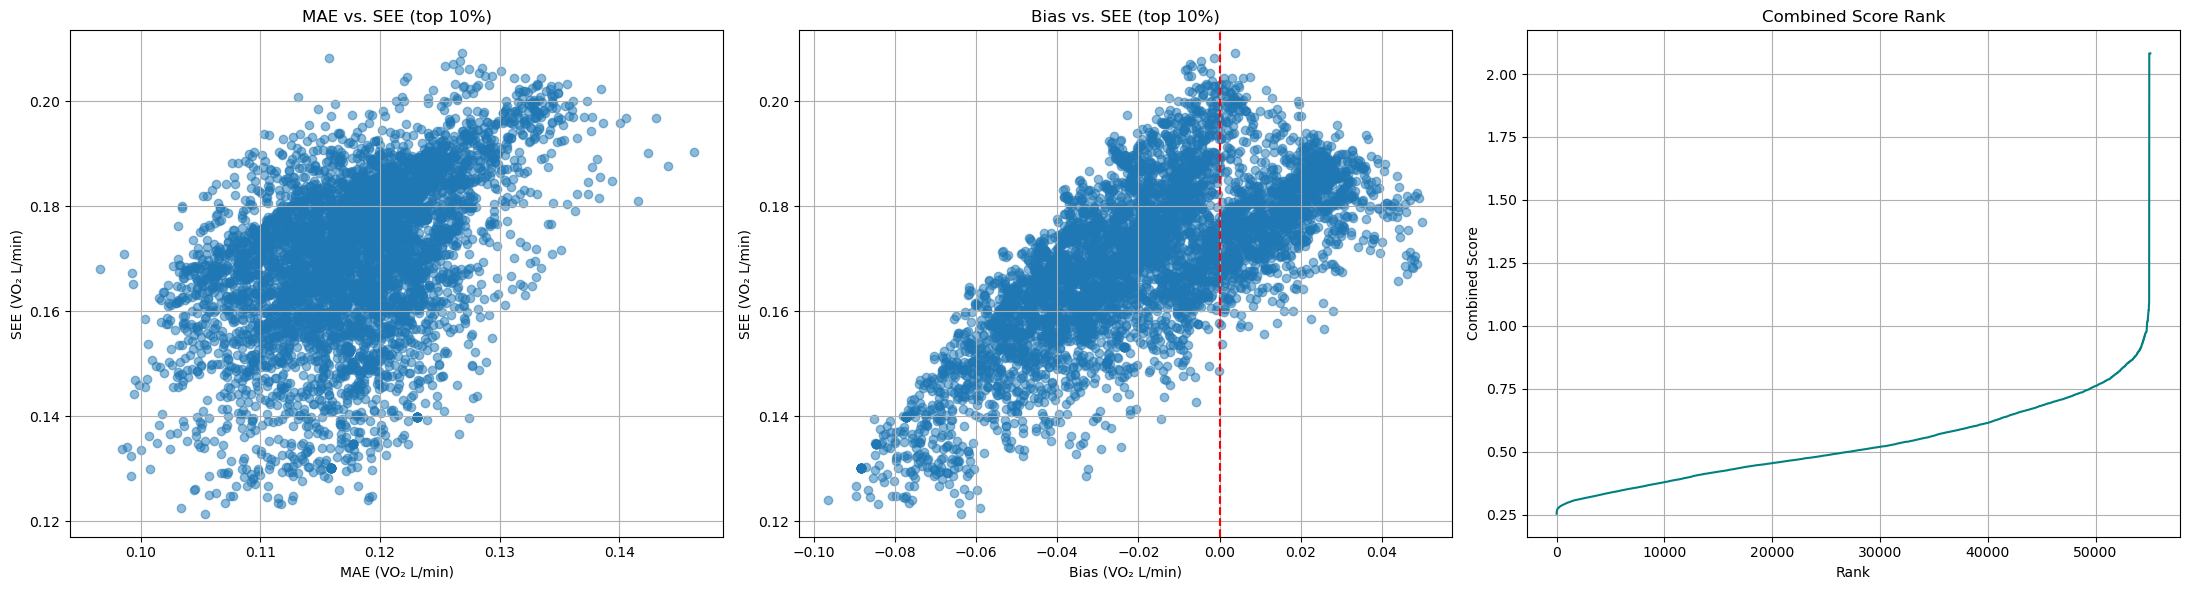

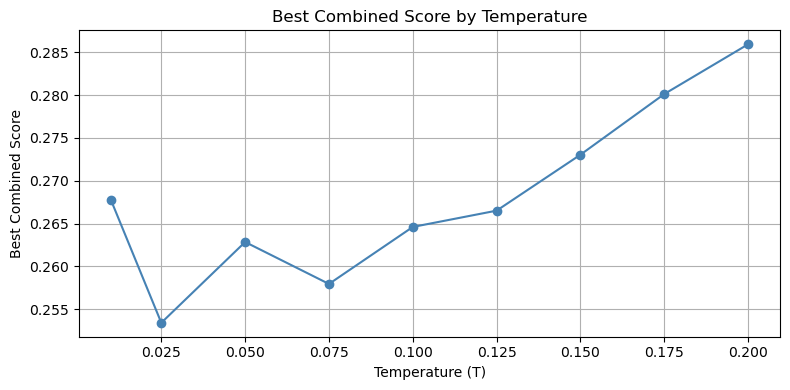

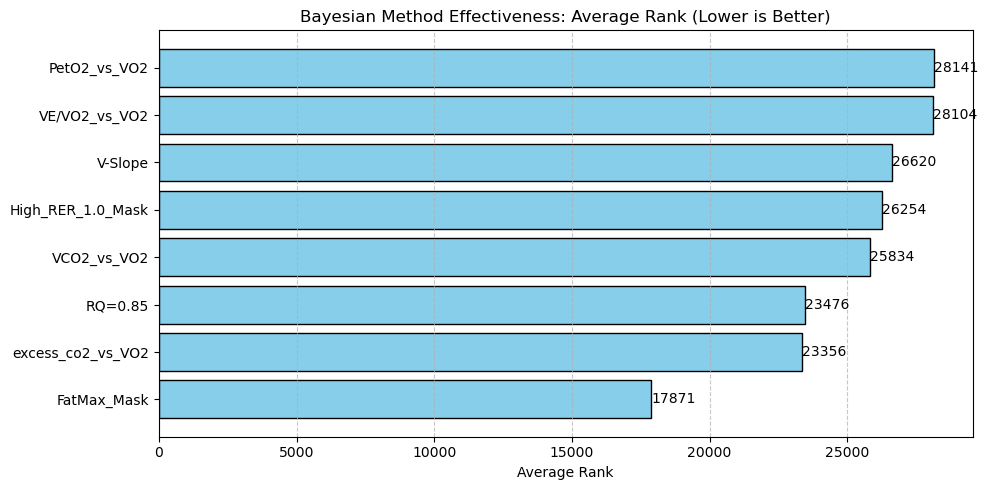

In [35]:
VT1_METHODS_POOL = [
    "V-Slope",
    "VCO2_vs_VO2",
    "VE/VO2_vs_VO2",
    "PetO2_vs_VO2",
    "excess_co2_vs_VO2",
    "RQ=0.85",
    "High_RER_1.0_Mask",
    "FatMax_Mask",
]
 
BAYESIAN_SMOOTH_TASKS = [
    # (smooth_methods, smooth_posterior, filter_type, sigma, label)
    (True,  True,  'gaussian', 0.5,  'Both Gaussian 0.5'),
    (True,  True,  'gaussian', 1.0,  'Both Gaussian 1.0'),
    (True,  True,  'gaussian', 2.0,  'Both Gaussian 2.0'),
    (True,  True,  'rolling',  3,    'Both Rolling 3pt'),
    (True,  True,  'rolling',  5,    'Both Rolling 5pt'),
    (True,  True,  'rolling',  7,    'Both Rolling 7pt')
]
 
TEMPERATURE_VALUES = [0.01, 0.025, 0.050, 0.075, 0.100, 0.125, 0.150, 0.175, 0.200]
 
# ── Load & pivot VT1 error data ───────────────────────────────────────────────
 
vt1_pivot = pd.read_csv('vt1_error_values.csv').pivot(
    index=['FileName', 'Time', 'VO2'],
    columns='Method',
    values='Normalized_Error'
).reset_index()
vt1_pivot.columns.name = None
 
# ── Exhaustive search ─────────────────────────────────────────────────────────
 
bayesian_combo_results = []
WEIGHT_STRATEGIES = [
    ('inverse_variance', inverse_variance_weights),
    ('uniform',          uniform_weights),
]
 
total_combos = sum(
    len(list(combinations(VT1_METHODS_POOL, r)))
    for r in range(1, len(VT1_METHODS_POOL) + 1)
) * len(BAYESIAN_SMOOTH_TASKS) * len(TEMPERATURE_VALUES) * len(WEIGHT_STRATEGIES)
 
print(f"Testing {total_combos:,} Bayesian configurations...")
tested = 0
 
for r in range(1, len(VT1_METHODS_POOL) + 1):
    for combo in combinations(VT1_METHODS_POOL, r):
        combo_list = list(combo)
 
        # Pre-compute weights once per combo × weight strategy
        weight_sets = {
            name: fn(results_df_original, combo_list) if name == 'inverse_variance'
                  else fn(combo_list)
            for name, fn in WEIGHT_STRATEGIES
        }
 
        for sm, sp, ft, sig, s_label in BAYESIAN_SMOOTH_TASKS:
            for temperature in TEMPERATURE_VALUES:
                for w_name, weights in weight_sets.items():
                    tested += 1
                    if tested % 2000 == 0:
                        print(f"  {tested:,} / {total_combos:,} tested...")
 
                    result = _score_bayesian_combo(
                        vt1_pivot, combo_list, weights,
                        smooth_methods=sm,
                        smooth_posterior=sp,
                        filter_type=ft,
                        sigma=sig,
                        temperature=temperature,
                        true_values=true_values,
                    )
                    if result is None:
                        continue
 
                    map_stats, mean_stats = result
                    base = {
                        'Weight_Strategy':  w_name,
                        'Smooth_Strategy':  s_label,
                        'Smooth_Methods':   sm,
                        'Smooth_Posterior': sp,
                        'Filter_Type':      ft,
                        'Sigma':            sig,
                        'Temperature':      temperature,
                        'Combination':      ' + '.join([m.split('_')[0] for m in combo_list]),
                        'Methods_Used':     combo_list,
                        'N_Methods':        len(combo_list),
                    }
                    for estimator, (mae, mean_err, see) in [('MAP', map_stats), ('Mean', mean_stats)]:
                        bayesian_combo_results.append({
                            **base,
                            'Estimator':  estimator,
                            'MAE':        mae,
                            'Mean_Error': mean_err,
                            'SEE':        see,
                        })
 
# ── Rank results ──────────────────────────────────────────────────────────────
 
bayes_results_df = pd.DataFrame(bayesian_combo_results)
bayes_results_df['Combined_Score'] = (
    bayes_results_df['MAE'] +
    bayes_results_df['Mean_Error'].abs() +
    bayes_results_df['SEE']
)
bayes_results_df = bayes_results_df.sort_values('Combined_Score').reset_index(drop=True)
 
bayes_results_df.to_csv('bayesian_vt1_ranked_combinations.csv', index=False)
 
print(f"\nDone. {len(bayes_results_df):,} valid configs ranked.")
print("\n── Top 20 Bayesian Configurations ──")
display(bayes_results_df.head(20))
 
# ── Visualize ─────────────────────────────────────────────────────────────────
 
filtered = bayes_results_df[bayes_results_df['Combined_Score'] < bayes_results_df['Combined_Score'].quantile(0.10)]
 
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))
 
ax1.scatter(filtered['MAE'], filtered['SEE'], alpha=0.5)
ax1.set_title('MAE vs. SEE (top 10%)')
ax1.set_xlabel('MAE (VO₂ L/min)'); ax1.set_ylabel('SEE (VO₂ L/min)'); ax1.grid(True)
 
ax2.scatter(filtered['Mean_Error'], filtered['SEE'], alpha=0.5)
ax2.axvline(0, color='red', linestyle='--')
ax2.set_title('Bias vs. SEE (top 10%)')
ax2.set_xlabel('Bias (VO₂ L/min)'); ax2.set_ylabel('SEE (VO₂ L/min)'); ax2.grid(True)
 
ax3.plot(bayes_results_df.index, bayes_results_df['Combined_Score'], color='teal')
ax3.set_title('Combined Score Rank')
ax3.set_xlabel('Rank'); ax3.set_ylabel('Combined Score'); ax3.grid(True)
 
plt.tight_layout()
plt.show()
 
# ── Temperature sensitivity plot ────────────────────────────────────────────────
 
temperature_summary = (
    bayes_results_df.groupby('Temperature')['Combined_Score']
    .min()
    .reset_index()
    .rename(columns={'Combined_Score': 'Best_Score'})
)
 
plt.figure(figsize=(8, 4))
plt.plot(temperature_summary['Temperature'], temperature_summary['Best_Score'],
         marker='o', color='steelblue')
plt.title('Best Combined Score by Temperature')
plt.xlabel('Temperature (T)'); plt.ylabel('Best Combined Score'); plt.grid(True)
plt.tight_layout()
plt.show()
 
# ── Average rank per method ───────────────────────────────────────────────────
 
method_ranks_bayes = {m: [] for m in VT1_METHODS_POOL}
for idx, row in bayes_results_df.iterrows():
    for method in row['Methods_Used']:
        if method in method_ranks_bayes:
            method_ranks_bayes[method].append(idx)
 
avg_rank_bayes_df = pd.DataFrame(
    {m: np.mean(ranks) if ranks else np.nan
     for m, ranks in method_ranks_bayes.items()},
    index=['Average_Rank']
).T.sort_values('Average_Rank')
 
plt.figure(figsize=(10, 5))
bars = plt.barh(avg_rank_bayes_df.index, avg_rank_bayes_df['Average_Rank'],
                color='skyblue', edgecolor='black')
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.5, bar.get_y() + bar.get_height() / 2, f'{w:.0f}', va='center')
plt.title('Bayesian Method Effectiveness: Average Rank (Lower is Better)')
plt.xlabel('Average Rank'); plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Section 6: Run Best Product of Experts Config & Generate Plots

##### Extract best configuration (or select desired configuration)

In [36]:
best_row = bayes_results_df.iloc[0]  # 0 is best, other configs found in bayesian_vt1_ranked_combinations.csv
 
BEST_VT1_COLS          = best_row['Methods_Used']
BEST_VT1_SMOOTH_BOTH   = best_row['Smooth_Methods']
BEST_VT1_SMOOTH_POST   = best_row['Smooth_Posterior']
BEST_VT1_FILTER        = best_row['Filter_Type']
BEST_VT1_SIGMA         = best_row['Sigma']
BEST_VT1_TEMPERATURE   = best_row['Temperature']
BEST_VT1_ESTIMATOR     = best_row['Estimator']      # 'MAP' or 'Mean'
BEST_VT1_WEIGHT_STRAT  = best_row['Weight_Strategy'] # 'inverse_variance' or 'uniform'

print("\n── Best VT1 Bayesian Configuration ──")
print(f"  Estimator  : {BEST_VT1_ESTIMATOR}")
print(f"  Weights    : {BEST_VT1_WEIGHT_STRAT}")
print(f"  Methods    : {BEST_VT1_COLS}")
print(f"  Filter     : {BEST_VT1_FILTER}  sigma={BEST_VT1_SIGMA}")
print(f"  Temperature: {BEST_VT1_TEMPERATURE}")
print(f"  Smooth both: {BEST_VT1_SMOOTH_BOTH}  |  Smooth posterior: {BEST_VT1_SMOOTH_POST}")
print(f"  MAE={best_row['MAE']:.4f}  Bias={best_row['Mean_Error']:.4f}  SEE={best_row['SEE']:.4f}  Score={best_row['Combined_Score']:.4f}")


── Best VT1 Bayesian Configuration ──
  Estimator  : Mean
  Weights    : inverse_variance
  Methods    : ['V-Slope', 'PetO2_vs_VO2', 'excess_co2_vs_VO2', 'FatMax_Mask']
  Filter     : gaussian  sigma=2.0
  Temperature: 0.025
  Smooth both: True  |  Smooth posterior: True
  MAE=0.1013  Bias=-0.0025  SEE=0.1496  Score=0.2534



── Weights (VT1 — inverse_variance) ──
   FatMax_Mask                     0.4883
   excess_co2_vs_VO2               0.2686
   PetO2_vs_VO2                    0.1273
   V-Slope                         0.1158

── VT1 Bayesian Results (Best Config — Mean estimator) ──


,FileName,Time,MAP_VO2,Mean_VO2,CI_5,CI_95,True_VO2,Best_Error
0,01 01 20260116 CPET BxB_20260210095828.xlsx,00:07:55,1.853371,1.785493,1.459880,2.125837,1.931,-0.145507
1,02 02 20260123 CPET BxB_20260210095834.xlsx,00:07:48,1.749666,1.751039,1.691118,1.790241,1.735,0.016039
2,03 03 20250213 CPET BxB_20260210095838.xlsx,00:07:35,1.535827,1.535295,1.441816,1.572777,1.564,-0.028705
3,04 04 20260115 CPET BxB_20260210095833.xlsx,00:05:58,1.330209,1.426626,1.303424,1.610893,1.428,-0.001374
4,05 05 20260126 CPET BxB_20260210095829.xlsx,00:08:37,1.359183,1.326652,1.194721,1.392405,1.344,-0.017348
5,06 06 20260127 CPET BxB_20260210095833.xlsx,00:06:38,2.547930,2.564710,2.329277,2.742112,2.807,-0.242290
6,07 07 20260114 CPET BxB_20260210095835.xlsx,00:07:45,2.247400,2.681261,2.186011,4.040872,2.504,0.177261
7,08 08 20260126 CPET BxB_20260210095839.xlsx,00:08:08,1.217813,1.217538,1.161692,1.240174,1.309,-0.091462
8,09 09 20260127 CPET BxB_20260210095826.xlsx,00:11:17,1.413397,1.327469,1.031698,1.421271,1.234,0.093469
9,10 10 20260128 CPET BxB_20260210095831.xlsx,00:09:49,1.517777,1.497447,1.252085,1.677426,1.478,0.019447



  Estimator : Mean
  MAE  : 0.1013 L/min
  Bias : -0.0025 L/min
  SEE  : 0.1520 L/min


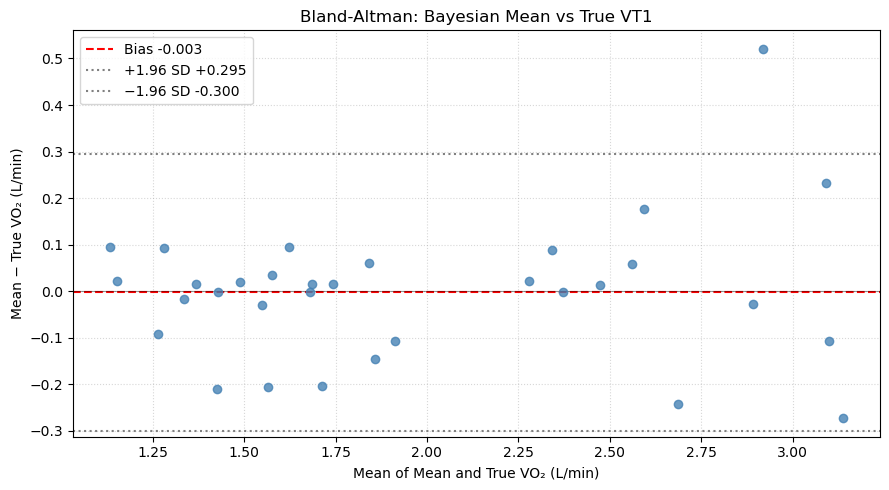

All VT1 posterior plots saved to 'VT1_Bayesian_Plots/'.


In [37]:
vt1_posterior_df, vt1_summary_df, vt1_weights = run_bayesian_vt_detection(
    error_csv            = 'vt1_error_values.csv',
    results_df_original  = results_df_original,
    cols_to_use          = BEST_VT1_COLS,
    smooth_methods       = BEST_VT1_SMOOTH_BOTH,
    smooth_posterior     = BEST_VT1_SMOOTH_POST,
    filter_type          = BEST_VT1_FILTER,
    sigma                = BEST_VT1_SIGMA,
    temperature          = BEST_VT1_TEMPERATURE,
    target_vt            = 'VT1',
)
 
# ── Accuracy summary ──────────────────────────────────────────────────────────
 
# Use whichever estimator won in Section 5
vt1_summary_df['True_VO2']  = vt1_summary_df['FileName'].map(true_values)
vt1_summary_df['Best_VO2']  = vt1_summary_df[f'{BEST_VT1_ESTIMATOR}_VO2']
vt1_summary_df['Best_Error'] = vt1_summary_df['Best_VO2'] - vt1_summary_df['True_VO2']
vt1_summary_df['Abs_Error']  = vt1_summary_df['Best_Error'].abs()
 
print(f"\n── VT1 Bayesian Results (Best Config — {BEST_VT1_ESTIMATOR} estimator) ──")
display(vt1_summary_df[['FileName', 'Time', 'MAP_VO2', 'Mean_VO2',
                          'CI_5', 'CI_95', 'True_VO2', 'Best_Error']])
 
print(f"\n  Estimator : {BEST_VT1_ESTIMATOR}")
print(f"  MAE  : {vt1_summary_df['Abs_Error'].mean():.4f} L/min")
print(f"  Bias : {vt1_summary_df['Best_Error'].mean():.4f} L/min")
print(f"  SEE  : {vt1_summary_df['Best_Error'].std():.4f} L/min")
 
vt1_summary_df.to_csv('vt1_bayesian_threshold_points.csv', index=False)
 
# ── Bland-Altman plot ─────────────────────────────────────────────────────────
 
valid     = vt1_summary_df.dropna(subset=['True_VO2'])
mean_vals = (valid['Best_VO2'] + valid['True_VO2']) / 2
diff_vals = valid['Best_VO2'] - valid['True_VO2']
bias      = diff_vals.mean()
loa       = 1.96 * diff_vals.std()
 
plt.figure(figsize=(9, 5))
plt.scatter(mean_vals, diff_vals, color='steelblue', alpha=0.8, zorder=3)
plt.axhline(bias,        color='red',   linestyle='--', label=f'Bias {bias:+.3f}')
plt.axhline(bias + loa,  color='gray',  linestyle=':',  label=f'+1.96 SD {bias+loa:+.3f}')
plt.axhline(bias - loa,  color='gray',  linestyle=':',  label=f'−1.96 SD {bias-loa:+.3f}')
plt.axhline(0,           color='black', linewidth=0.8, alpha=0.4)
plt.title(f'Bland-Altman: Bayesian {BEST_VT1_ESTIMATOR} vs True VT1')
plt.xlabel(f'Mean of {BEST_VT1_ESTIMATOR} and True VO₂ (L/min)')
plt.ylabel(f'{BEST_VT1_ESTIMATOR} − True VO₂ (L/min)')
plt.legend(); plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()
 
# ── Batch posterior plots ─────────────────────────────────────────────────────
 
plot_bayesian_posterior(
    posterior_df  = vt1_posterior_df,
    summary_df    = vt1_summary_df,
    cols_to_use   = BEST_VT1_COLS,
    true_values   = true_values,
    output_folder = 'VT1_Bayesian_Plots',
)
 
print("All VT1 posterior plots saved to 'VT1_Bayesian_Plots/'.")